In [1]:
# 1. Make sure internet is ON for this notebook (Settings panel on the right → Internet → On)

# 2. Auto-accept the MS EULA and install the font package
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get update -qq
!apt-get install -y ttf-mscorefonts-installer -qq

# 3. Rebuild matplotlib's font cache so it picks up the new font
import matplotlib.font_manager as fm
import subprocess

# find the installed Georgia files and register them directly
georgia_paths = subprocess.run(["fc-list", ":family=Georgia"], capture_output=True, text=True).stdout
print(georgia_paths)

for line in georgia_paths.strip().split("\n"):
    if line:
        path = line.split(":")[0]
        fm.fontManager.addfont(path)

# 4. Confirm it's available
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Georgia'
print("Georgia" in {f.name for f in fm.fontManager.ttflist})

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package libmspack0:amd64.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libmspack0_0.10.1-2build2_amd64.deb ...
Unpacking libmspack0:amd64 (0.10.1-2build2) ...
Selecting previously unselected package cabextract.
Preparing to unpack .../01-cabextract_1.9-3_amd64.deb ...
Unpacking cabextract (1.9-3) ...
Selecting previously unselected package xfonts-encodings.
Preparing to unpack .../02-xfonts-encodings_1%3a1.0.5-0ubuntu2_all.deb ...
Unpacking xfonts-encodings (1:1.0.5-0ubuntu2) ...
Selecting previously unselected package xfonts-utils.
Preparing to unpack .../03-xfonts-utils_1%3a7.7+6build2_amd64.deb ...
Unpacking xfonts-utils (1:7.7+6build2) ...
Selecting previously unselected package pyth

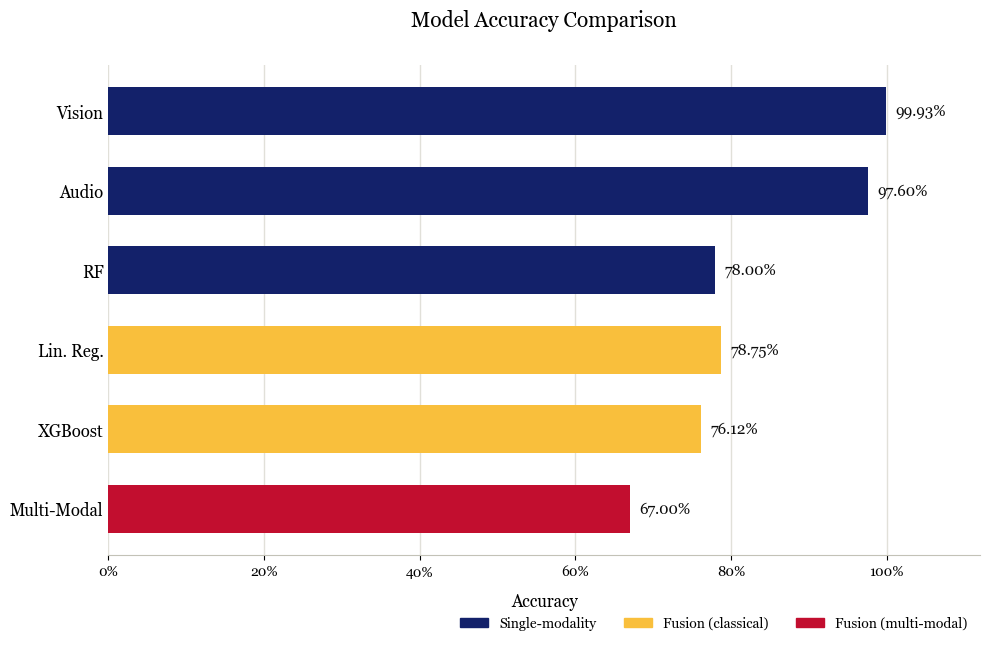

In [2]:
"""
Model accuracy comparison — horizontal bar chart.
Runs on Kaggle with Internet OFF — uses matplotlib's built-in DejaVu Sans,
no apt-get / font install required.
"""
 
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
 
# ── data ──────────────────────────────────────────────────────────
# order chosen so same-color groups stay together (not sorted purely by value)
accuracies = {
    "Vision":             0.9993,
    "Audio":              0.9760,
    "RF":                 0.7800,
    "Lin. Reg.":          0.7875,
    "XGBoost":            0.7612,
    "Multi-Modal":        0.67,
}
 
group = {
    "Vision":             "single",
    "Audio":              "single",
    "RF":                 "single",
    "Lin. Reg.":          "fusion_classical",
    "XGBoost":            "fusion_classical",
    "Multi-Modal":        "fusion_multimodal",
}
 
colors = {
    "single":              "#13216a",
    "fusion_classical":    "#f9bf3c",
    "fusion_multimodal":   "#c20e2f",
}
 
# already ranked high -> low; keep that order top-to-bottom
labels = list(accuracies.keys())
values = [v * 100 for v in accuracies.values()]
bar_colors = [colors[group[label]] for label in labels]
 
# ── plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.6))
 
y_pos = range(len(labels))
bars = ax.barh(y_pos, values, color=bar_colors, height=0.6, zorder=3)
 
# invert so the highest value is at the top
ax.invert_yaxis()
 
# value labels at the end of each bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center", ha="left",
        fontsize=11, fontweight="medium", color="#0b0b0b",
    )
 
# axes cosmetics
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlim(0, 112)
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlabel("Accuracy", fontsize=12, labelpad=10)
 
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#e1e0d9", linewidth=1, zorder=0)
ax.yaxis.grid(False)
 
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="y", length=0)
 
ax.set_title("Model Accuracy Comparison", fontsize=15, pad=28, loc="center")
 
# legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["single"], label="Single-modality"),
    plt.Rectangle((0, 0), 1, 1, color=colors["fusion_classical"], label="Fusion (classical)"),
    plt.Rectangle((0, 0), 1, 1, color=colors["fusion_multimodal"], label="Fusion (multi-modal)"),
]
ax.legend(
    handles=legend_handles, loc="lower right", frameon=False,
    fontsize=10, bbox_to_anchor=(1.0, -0.18), ncol=3,
)
 
fig.tight_layout()
fig.savefig("/kaggle/working/accuracy_comparison_horizontal.png", dpi=200, bbox_inches="tight")
plt.show()